In [1]:
import math
import random
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd
# !pip install mesa
from mesa import Agent, Model
from mesa.time import BaseScheduler
from mesa.datacollection import DataCollector
import seaborn as sns
sns.set()

from simulation_settings import setting_default, default_increments, mceldoon

from scipy.stats import ttest_ind

In [2]:
# Sigmoid function is used to find the probability of learning a new node given the learners' nodes and edges
def sigmoid(x, b=1):
  return(1 / (1 + math.exp(-(3.5 * x -b))))

In [3]:
sigmoid(sigmoid(sigmoid(1)))

0.8967447171440864

In [4]:
class ICAPModel(Model):
  def __init__(self, knowledge_graph, agents_type, increments, time_per_step_dict = None, 
               max_time = 100.0):

    self.knowledge_graph = knowledge_graph
    self.agents_type = agents_type
    self.agent_types_changed = {x: False for x in agents_type.keys()}
    # Should be a dictionary mapping learner type strings to integers
    if time_per_step_dict != None:
      self.time_dict = time_per_step_dict
    else:
      self.time_dict = {'non-learner': 1, 'passive': 1, 'active': 1, 'constructive': 1, 'interactive': 1} 
    self.max_time = max_time 
    self.schedule = BaseScheduler(self)
    agent_count = 0
    self.focal_nodes = []
    self.fc = False
    self.increments = increments

    for learner_type, config in self.agents_type.items():
      for _ in range(config['count']):
        a = Learner(agent_count, self, learner_type, config, knowledge_graph)
        agent_count += 1
        self.schedule.add(a)

    self.knowledge_graph = knowledge_graph
    self.node = 0

    # This just sets up data collection for each variable of interest for every 
    # agent at every step, which can later be extracted as a dataframe.
    self.datacollector = DataCollector(
      model_reporters={},
      agent_reporters={'AgentType': 'type', 'GroupType': 'group_type', 'Knowledge':'knowledge_amount', 
        'KnowledgeLinks':'knowledge_links', 'Time': 'time', 'AverageMastery' : 'average_mastery'}
      )
    self.pairs = {}
    for k in agents_type.keys():
      self.pair_agents(k)

  # Randomly pairs each interactive agent with another interactive agent.
  def pair_agents(self, group_type=None):
    if group_type and not self.fc:
      interactive_agents = [agent for agent in self.schedule.agents if 
                              agent.type == 'interactive' and agent.group_type == group_type]
    else:
      interactive_agents = [agent for agent in self.schedule.agents if 
                              agent.type == 'interactive']
    random.shuffle(interactive_agents)
    for i in range(0, len(interactive_agents) - 1, 2):
      # if self.complement_knowledge:
      #   known_nodes = random.sample(list(self.knowledge_graph.nodes), self.nodes_known_before)
      #   interactive_agents[i].known_nodes = known_nodes
      #   known_nodes_complement = random.sample(list(set(self.knowledge_graph.nodes) - set(known_nodes)),
      #                                          self.nodes_known_before)
      #   interactive_agents[i + 1].known_nodes = known_nodes_complement
      self.pairs[interactive_agents[i]] = interactive_agents[i + 1]
      self.pairs[interactive_agents[i + 1]] = interactive_agents[i]
      
  def step(self, node_skip = 1):
    # if self.schedule.time == 0:
      # for learner in self.schedule.agents:
      #   learner.update_focal_nodes()
    # This collects the data as specified above for the current step.
    self.datacollector.collect(self)
    self.schedule.step()
    
    for agent_type, changed in self.agent_types_changed.items():
      if changed:
        self.pair_agents(group_type=agent_type)
        self.agent_types_changed[agent_type] = False
        
    self.node += node_skip
    # self.focal_nodes = self.focal_nodes + [self.node]
    graph_size = self.knowledge_graph.number_of_nodes()
    
    # if self.ps:
    #   for k in self.agents_type.keys():
    #     self.pair_agents(k)
    
    if self.node >= graph_size:
        if graph_size % node_skip == 0:
            self.node -= graph_size - 1
        else: self.node -= graph_size

In [269]:
class Learner(Agent):
  def __init__(self, id, model, learner_type, time_config, knowledge_graph):
    super().__init__(id, model)
    self.knowledge = []
    self.knowledge_links = []
    self.time_config = time_config
    # if self.type == 'interactive':
    self.knowledge_graph = knowledge_graph.copy()
    self.interacted = False
    self.time = 0.0
    self.group_type = time_config['name']
    self.type = list(time_config["order"].keys())[0]
    self.initiate_mastery_levels()
    self.practicing_node = 0
    self.practice_number = [0] * len(self.model.knowledge_graph)
    self.max_practice = 4
    self.cycle_count = 0

  @property
  def average_mastery(self):
    return sum(self.mastery.values()) / len(self.mastery)

  @property
  def knowledge_amount(self):
    return sum(1 for x in self.mastery.values() if x > 0.7)

  def mastery_gained(self):
    return self.mastery[self.practicing_node] > 0.8

  def initiate_mastery_levels(self):
    self.mastery = {}
    for node in self.model.knowledge_graph:
      self.mastery[node] = random.uniform(0, 0.1)

  def get_learning_strength_for_node(self, node, partner=None):
    if not partner:
      subgraph_nodes = self.knowledge + [node]
      subgraph = self.model.knowledge_graph.subgraph(subgraph_nodes)
      return subgraph.degree(node, weight='weight')
    else:
      self_subgraph_nodes = self.knowledge + [node]
      self_subgraph = self.model.knowledge_graph.subgraph(self_subgraph_nodes)
      partner_subgraph_nodes = partner.knowledge + [node]
      partner_subgraph = partner.model.knowledge_graph.subgraph(partner_subgraph_nodes)
      intersection_graph = nx.intersection(self_subgraph, partner_subgraph)
      for (u, v) in intersection_graph.edges():
        intersection_graph.edges[u, v]['weight'] = self.model.knowledge_graph.edges[u, v]['weight']
      all_edges = (1/2) * partner_subgraph.degree(node, weight='weight') + self_subgraph.degree(node, weight='weight')
      return all_edges - (1/2) * intersection_graph.degree(node, weight='weight') 

  # This function implements how agents can learn a node and returns a Boolean
  # specifying whether or not they have learned the node. It has three parameters:
  #  - node: the node to be learned
  #  - easiness: a number specifying how easy the node is to be learned. This parameter
  #              will go into a sigmoidal function to determine the probability of 
  #              learning the node.   
  #  - active: This is a boolean that should be true the agent is an active,
  #            constructive, or interactive learner, and False if the agent
  #            is a passive learner. If True, it adds the sum of the weights
  #            from neighboring nodes in self.knowledge into the sigmoidal
  #            function, and if the node is learned, it adds all the edges to
  #            the node to self.knowledge_links. 
  
  # def increase_mastery(self, node, easiness):
  #   self.mastery[node] = min(1, self.mastery[node] + random.uniform(0, self.model.increments[self.type]) * easiness)

  # def update_mastery(self, node, neighbor, easiness):
  #   self.mastery[node] = min(1, self.mastery[node] + random.uniform(0, self.model.increments[self.type]) * \
  #     self.model.knowledge_graph.edges[node, neighbor]['weight'])

  def practice(self, node, easiness = 1.0, active = True, partner=None):
    # self.practice_number[self.practicing_node] += 1
    new_mastery = 0
    if active:
      for neighbor in self.knowledge_graph.neighbors(node):
        new_mastery += self.knowledge_graph.edges[node, neighbor]['weight'] * self.mastery[neighbor]
    self.mastery[node] = sigmoid(new_mastery + self.mastery[node], b = self.model.increments[self.type])


  # This function is given a node and returns the list of neighbors for that node
  # sorted by how many neighbors each neighboring node has in self.knowledge.
  # Ties are broken randomly.
  def sort_neighbors(self, node, knowledge_graph=None):
    if not knowledge_graph:
      knowledge_graph = self.model.knowledge_graph
    neighbors = knowledge_graph.neighbors(node)
    key = lambda n: len(set(knowledge_graph.neighbors(n)).intersection(set(self.knowledge))) + random.random()
    return sorted(neighbors, key = key, reverse=True)

  # This function implements an interactive learning session between two agents
  # (self and partner). The function does not return anything but modifies
  # the knowledge state directly
  def interactive_practice(self, partner):
    neighbors = list(self.knowledge_graph.neighbors(self.practicing_node))
    if not neighbors:
      return
    sorted_neighbors = sorted(neighbors, key=lambda x: self.knowledge_graph.edges[self.practicing_node, x]['weight'])
    self_edge = self.knowledge_graph.edges[self.practicing_node, neighbors[0]]
    partner_edge = partner.knowledge_graph.edges[self.practicing_node, neighbors[0]]
    max_weight = max(self_edge['weight'], partner_edge['weight'] )

    if self_edge['weight'] == partner_edge['weight']:
      self_edge['weight'] += min(self_edge['weight'] + .15, 1)
      partner_edge['weight'] = self_edge['weight']
    else:
      self_edge['weight'] = max_weight
      partner_edge['weight'] = max_weight

    if len(neighbors) > 1:
      self_edge = self.knowledge_graph.edges[self.practicing_node, neighbors[1]]
      partner_edge = partner.knowledge_graph.edges[self.practicing_node, neighbors[1]]
      max_weight = max(self_edge['weight'], partner_edge['weight'] )
      if self_edge['weight'] == partner_edge['weight']:
        self_edge['weight'] += min(self_edge['weight'] + .15, 1)
        partner_edge['weight'] = self_edge['weight']
      else:
        self_edge['weight'] = max_weight
        partner_edge['weight'] = max_weight

  def update_focal_nodes(self): # Used for comparing pre- and post-test results with empirical data
    if self.prior_knowledge:
      self.posttest_knowledge = [x for x in self.prior_knowledge if x in self.model.focal_nodes]
  
  def reinforce_edges(self):
    neighbors = list(self.knowledge_graph.neighbors(self.practicing_node))
    if not neighbors:
      return
    self.knowledge_graph.edges[self.practicing_node, neighbors[0]]['weight'] = min(
      1, self.knowledge_graph.edges[self.practicing_node, neighbors[0]]['weight'] + 0.15
    )
    if len(neighbors) > 1:
      self.knowledge_graph.edges[self.practicing_node, neighbors[1]]['weight'] = min(
        1, self.knowledge_graph.edges[self.practicing_node, neighbors[1]]['weight'] + 0.10
      )

  # This function implements a single step that the agent takes. It has three parameters:
  # It only takes a step if the agent has enough time (as measured by self.time)
  # as compared to the maximum alloted time for the model (self.model.max_time).
  # The agent then takes the appropriate step depending on the agent type.
  # Most of the work happens in the self.learn and self.interactive_learn methods.
  def step(self):
    if self.time <= self.model.max_time - self.model.time_dict[self.type]:
      # if self.mastery_gained():
      #   if self.practicing_node == len(self.model.knowledge_graph) - 1:
      #     # self.type = 'non-learner'
      #     self.practicing_node = 0
      #   else:
      #     self.practicing_node += 1
      if self.type == 'non-learner':
        pass
      if self.type == 'passive':
        self.practice(self.practicing_node, active=False)
      elif self.type == 'active':
        self.practice(self.practicing_node)
      elif self.type == 'constructive':
        self.practice(self.practicing_node)
        self.reinforce_edges()
      elif self.type == 'interactive':
        # self.interacted will be true if the agent's partner already had a step.
        # If it is True, it means the agent already took a step (during the partner's)
        # "turn", and so we can skip this step and set self.interacted to be False.
        if self.interacted:
          self.interacted = False
        else:
          partner = self.model.pairs[self]
          
          self.practice(self.practicing_node)
          partner.practice(self.practicing_node)
          self.interactive_practice(partner)
          partner.interacted = True
      self.practicing_node += 1
      if self.practicing_node % self.max_practice == 0:
        self.practicing_node -= self.max_practice
        self.cycle_count += 1
        if self.cycle_count == 5:
          self.cycle_count = 0
          self.practicing_node += self.max_practice
          if self.practicing_node >= len(self.model.knowledge_graph):
            self.type = 'non-learner'
      if self.type == 'non-learner':
        return      

      # if self.practice_number[self.practicing_node] == self.max_practice:
      #   self.practicing_node += 1
        # if self.practicing_node == len(self.model.knowledge_graph):
        #   self.type == 'non-learner'
      if self.time == int(self.model.max_time * self.time_config['order'][self.type]):
        next_type_index = list(self.time_config['order'].keys()).index(self.type) + 1
        previous_type = self.type
        self.type = list(self.time_config['order'].keys())[next_type_index]
        # self.type = 'active'
        # self.practicing_node //= 3
        # if self.type == 'passive':
      #   if self.type == 'interactive' or previous_type == 'interactive':
      #     self.model.agent_types_changed[self.group_type] = True
      self.time += self.model.time_dict[self.type]

In [13]:
def simulate_ICAP_learning(model, num_steps = 50, node_skip = 1):
  model.focal_nodes = [x for x in range(0, node_skip * num_steps, node_skip)]
  for i in range(num_steps):
    model.step(node_skip)

  agents_df = model.datacollector.get_agent_vars_dataframe()
  # agents_df['KnowledgeAmount'] = [len(x) for x in agents_df.Knowledge]
  agents_df['LargestSubgraph'] = [len(max(nx.connected_components(nx.Graph(x)))) if x != [] else 1 for x in agents_df.KnowledgeLinks]
  return agents_df

def plot_ICAP_learning(agents_df, agents_type, y = 'Knowledge'):
  for agent_type in agents_type.keys():
    plot_df = agents_df[agents_df.GroupType == agent_type][['Time', 'Knowledge', 'AverageMastery']]
    mean_df = plot_df.groupby(by='Step').mean()
    min_df = plot_df.groupby(by='Step').min()
    max_df = plot_df.groupby(by='Step').max()
    plt.plot(mean_df.Time, mean_df[y], label=agent_type)
    plt.fill_between(min_df.Time, y1 = min_df[y], y2 = max_df[y], alpha = 0.2)
  plt.xlabel('Step')
  plt.ylabel(y)
  plt.legend()
  plt.show()

[6]


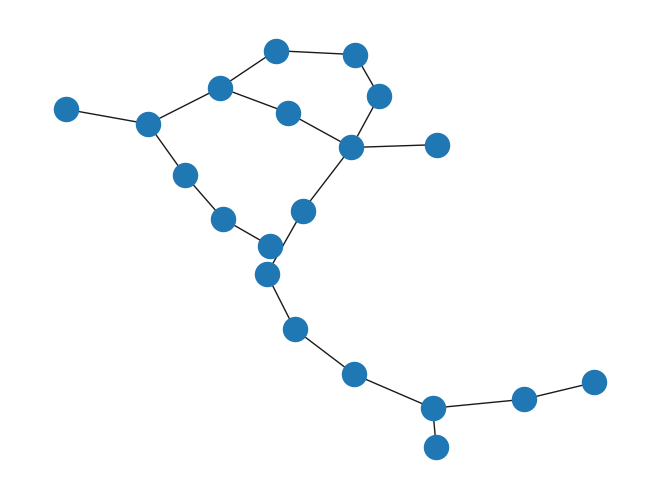

In [265]:
num_nodes, k, p = 20, 3, 0.9
knowledge_graph = nx.watts_strogatz_graph(num_nodes, k, p)
nx.draw(knowledge_graph)
print(list(knowledge_graph.neighbors(0)))

In [191]:
sccs = list(nx.connected_component_subgraphs(knowledge_graph))
sccs

AttributeError: module 'networkx' has no attribute 'connected_component_subgraphs'

In [273]:
a = 0.6
default_bs = {
  'non-learner': 0 ,
  'passive': 0.5 + a,
  'active': 0.65 + a,
  'constructive': .8 + a,
  'interactive': 1. + a
}

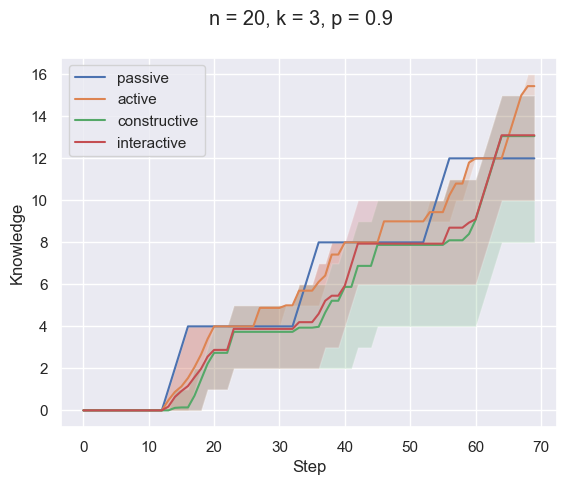

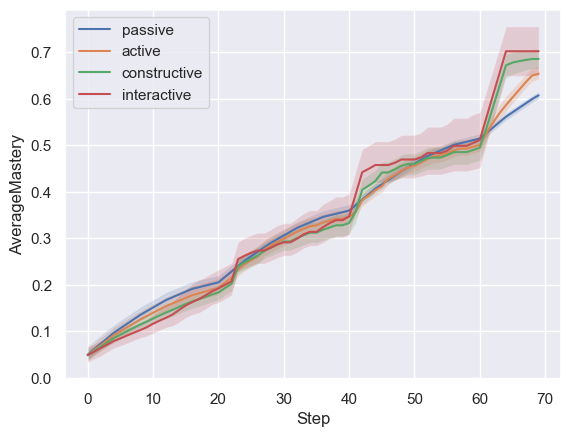

In [275]:
agents_type = setting_default

for (u, v) in knowledge_graph.edges():
  knowledge_graph.edges[u,v]['weight'] = random.uniform(0, 0.3)

# knowledge_graph.clear_edges()

model = ICAPModel(knowledge_graph, agents_type=agents_type, max_time = 100, increments=default_bs)
df = simulate_ICAP_learning(model, 70, node_skip = 2)
plt.suptitle('n = {}, k = {}, p = {}'.format(num_nodes, k, p))
plot_ICAP_learning(df, agents_type=agents_type, y = 'Knowledge')
plot_ICAP_learning(df, agents_type=agents_type, y = 'AverageMastery')


In [10]:
df[(df['GroupType'] == 'group_1')]['Knowledge'].loc[39].mean()

KeyError: 39

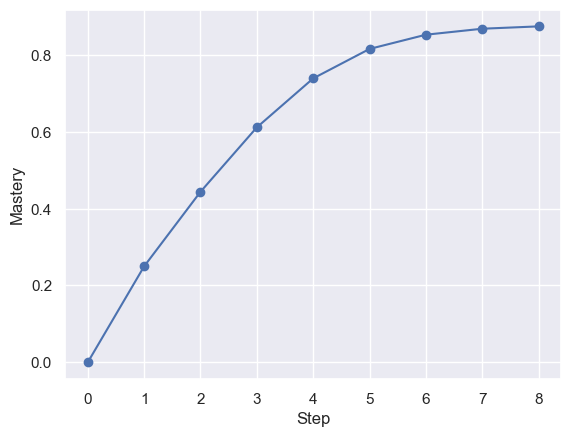

In [ ]:
x = 0

# Define the number of steps
num_steps = 8

# Lists to hold the step numbers and corresponding sigmoid values
steps = [0]
sig_values = [0]

for step in range(num_steps):
    y = sigmoid(x, b = 1.1)
    steps.append(step + 1)
    sig_values.append(y)
    
    # Use the output y as the input x for the next step
    x = y

plt.plot(steps, sig_values, marker='o')
plt.xlabel('Step')
plt.ylabel('Mastery')
# plt.title('''Passive leaner's mastery over a node through steps''')
plt.grid(True)
plt.savefig('sigmoid_plot.png', format='png', dpi=300)


[0.403, 0.491] [0.5, 0.554]


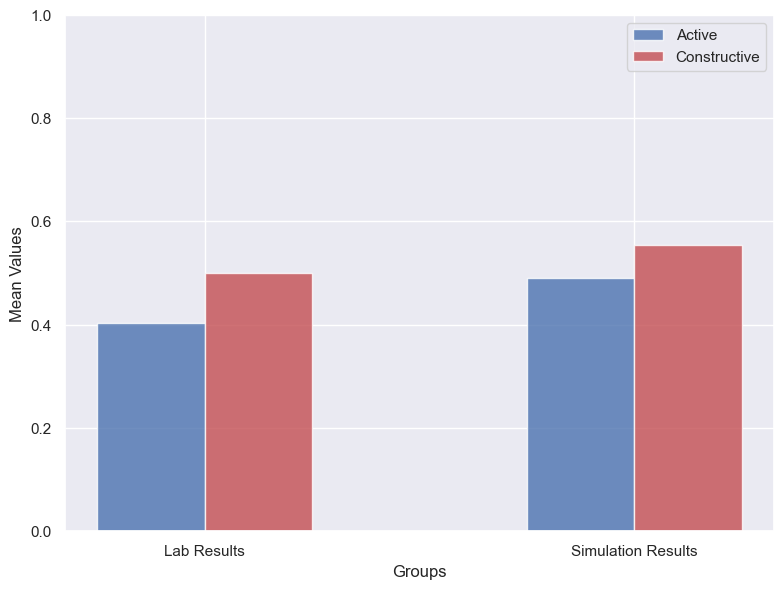

In [ ]:
df[(df['AgentType'] == 'constructive')]['Knowledge'].loc[39].mean()

# Define the synthetic data
groups = ['Lab Results', 'Simulation Results']
active_mean = [.403, df[(df['GroupType'] == 'group_1')]['Knowledge'].loc[39].mean() / 20]
constructive_mean = [.500, df[(df['GroupType'] == 'group_2')]['Knowledge'].loc[39].mean()/20]

# Define bar width
bar_width = 0.25

# Set up the figure and axis
fig, ax = plt.subplots(figsize=(8, 6))

# Arrange the groups on the X-axis
index = np.arange(len(groups))
print(active_mean, constructive_mean)
# Plot bars
bar1 = plt.bar(index, active_mean, bar_width, label='Active', alpha=0.8, color='b')
bar2 = plt.bar(index + bar_width, constructive_mean, bar_width, label='Constructive', alpha=0.8, color='r')

# Labeling
plt.xlabel('Groups')
plt.ylabel('Mean Values')
# plt.title('Comparison of Simulation and Experiment Results')
plt.xticks(index + bar_width / 2, groups)  # Positioning the group labels in the center of the grouped bars
plt.legend()
plt.tight_layout()
plt.ylim(0, 1)
# plt.show()
plt.savefig('replication_mceldoon.png')
